# An attempt to construct a variational autoencoder(based on Troels´ autoencoder example)

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import random 

from torch.utils.data import Dataset, DataLoader
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
import umap
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster
from sklearn import manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import itertools

### Data loading

In [2]:
#Getting the images:
unique_path = r"../data\grand_scraper_folder\unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []




#Folder with folders of images:
base_folder = r"../data\scrandle_padded_low_res_data"

current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    image_Data_low_res.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

Processing 2025-04-20:0_left.webp
Processing 2025-04-20:0_right.webp
Processing 2025-04-20:1_left.webp
Processing 2025-04-20:1_right.webp
Processing 2025-04-20:2_left.webp
Processing 2025-04-20:2_right.webp
Processing 2025-04-20:3_left.webp
Processing 2025-04-20:3_right.webp
Processing 2025-04-20:4_left.webp
Processing 2025-04-20:4_right.webp
Processing 2025-04-20:5_left.webp
Processing 2025-04-20:5_right.webp
Processing 2025-04-20:6_left.webp
Processing 2025-04-20:6_right.webp
Processing 2025-04-20:7_left.webp
Processing 2025-04-20:7_right.webp
Processing 2025-04-20:8_left.webp
Processing 2025-04-20:8_right.webp
Processing 2025-04-20:9_left.webp
Processing 2025-04-20:9_right.webp
Processing 2025-04-21:0_left.webp
Processing 2025-04-21:0_right.webp
Processing 2025-04-21:1_left.webp
Processing 2025-04-21:1_right.webp
Processing 2025-04-21:2_left.webp
Processing 2025-04-21:2_right.webp
Processing 2025-04-21:3_left.webp
Processing 2025-04-21:3_right.webp
Processing 2025-04-21:4_left.webp


In [51]:
#Getting only the images:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

image_train = torch.from_numpy(np.array(image_only_low_res[:3800])/255).permute(0,3,1,2).float().to(device)
image_test = torch.from_numpy(np.array(image_only_low_res[3800:])/255).permute(0,3,1,2).float().to(device)

Using Device: cuda


In [52]:
#Next, for the dataloader:
class ImageDataset(Dataset):
    def __init__(self, images):
        
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        return image

dataset_train = ImageDataset(image_train)
dataset_test = ImageDataset(image_test)
loader_train = DataLoader(dataset_train, batch_size=80, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=80, shuffle=True)

### Model(Adapted from Troels autoencoder example solution)

In [303]:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(11*9*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 11*9*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 11, 9))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(0,1)),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(1,0))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [312]:
# Define loss function and training parameters:
# Define the loss function
loss_fn = nn.L1Loss()

# Define an optimizer (both for the encoder and the decoder!)
lr = 0.001

# Set the random seed for reproducible results
torch.manual_seed(42)

# Initialize the two networks
#NOTE: d was initially 4
d = 30
encoder = Encoder(encoded_space_dim=d, fc2_input_dim=128).to(device)
decoder = Decoder(encoded_space_dim=d, fc2_input_dim=128).to(device)
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)
optim

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)

In [516]:
#New learning rates:
lr = 0.000001
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]
#loss_fn = nn.L1Loss()
optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)
optim

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-06
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-06
    maximize: False
    weight_decay: 1e-05
)

In [517]:
# Define training and validation functions:

### Training function
def train_epoch(encoder, decoder, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    encoder.train()
    decoder.train()
    train_loss = []
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for image_batch in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Encode data
        encoded_data = encoder(image_batch)
        # Decode data
        decoded_data = decoder(encoded_data)
        #test = decoded_data.detach().cpu()
        #break
        #Prining the decoded image:
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
#         print('\t partial train loss (single batch): %f' % (loss.data))
        train_loss.append(loss.detach().cpu().numpy())

    return np.mean(train_loss)
    #return test


### Testing function
def test_epoch(encoder, decoder, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_out = []
        conc_label = []
        for image_batch in dataloader:
            # Encode data
            encoded_data = encoder(image_batch)
            # Decode data
            decoded_data = decoder(encoded_data)
            # Append the network output and the original image to the lists
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # Create a single tensor with all the values in the lists
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label) 
        # Evaluate global loss
        val_loss = loss_fn(conc_out, conc_label)
    return val_loss.data

In [518]:
# Train the model
num_epochs = 500
diz_loss = {'train_loss':[],'val_loss':[]}
for epoch in range(num_epochs):
    train_loss = train_epoch(encoder,decoder, loader_train, loss_fn, optim)
    val_loss = test_epoch(encoder,decoder,loader_test,loss_fn)
    print('\n EPOCH {}/{} \t train loss {} \t val loss {}'.format(epoch + 1, num_epochs,train_loss,val_loss))
    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)


 EPOCH 1/500 	 train loss 0.06858592480421066 	 val loss 0.09267269819974899

 EPOCH 2/500 	 train loss 0.06849689036607742 	 val loss 0.09280432760715485

 EPOCH 3/500 	 train loss 0.06857750564813614 	 val loss 0.09271654486656189

 EPOCH 4/500 	 train loss 0.06852711737155914 	 val loss 0.0926855280995369

 EPOCH 5/500 	 train loss 0.06853622198104858 	 val loss 0.09269252419471741

 EPOCH 6/500 	 train loss 0.06848444044589996 	 val loss 0.09280560165643692

 EPOCH 7/500 	 train loss 0.06848449259996414 	 val loss 0.09272661060094833

 EPOCH 8/500 	 train loss 0.06848493963479996 	 val loss 0.09272933751344681

 EPOCH 9/500 	 train loss 0.06862932443618774 	 val loss 0.09268086403608322

 EPOCH 10/500 	 train loss 0.06863602995872498 	 val loss 0.09272585064172745

 EPOCH 11/500 	 train loss 0.06851755827665329 	 val loss 0.09271664917469025

 EPOCH 12/500 	 train loss 0.06849160045385361 	 val loss 0.09270856529474258

 EPOCH 13/500 	 train loss 0.06848044693470001 	 val loss 0.0

KeyboardInterrupt: 

In [519]:
encoder.eval()
decoder.eval()
#Trying to get a reconstructed image:
#reconstruct = (decoder(encoder(images[0].unsqueeze(1).permute(1,0,2,3).to(device))).detach().cpu().numpy()[0]).transpose(1, 2, 0)

Decoder(
  (decoder_lin): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=3168, bias=True)
    (3): ReLU(inplace=True)
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(32, 11, 9))
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), output_padding=(0, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(8, 3, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 0))
  )
)

In [520]:

def check_encoder(image_id, train_test):
    reconstruct = decoder(encoder(train_test[image_id].unsqueeze(1).cpu().permute(1,0,2,3).to(device))).detach().cpu().numpy()[0].transpose(1,2,0)
    original = train_test[image_id].cpu().numpy().transpose(1,2,0)
    return reconstruct, original


Showing image comparison for image nr. 2753


<Figure size 1200x12000 with 0 Axes>

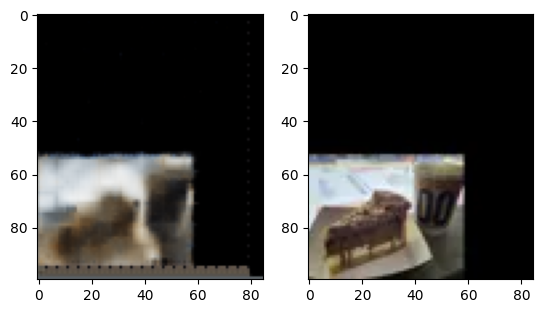

In [531]:
plt.figure(figsize=(12, 120))
random_num = np.random.randint(0, 3799)
image_id = random_num#390
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
print("Showing image comparison for image nr.", random_num)
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoder(image_id, image_train)[0])
axarr[1].imshow(check_encoder(image_id, image_train)[1])



In [522]:
random_num

3265

Showing image comparison for image nr. 627


<Figure size 1200x12000 with 0 Axes>

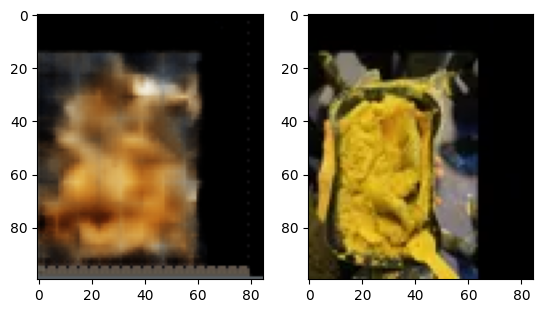

In [543]:
plt.figure(figsize=(12, 120))
random_num2 = np.random.randint(0, len(image_only_low_res[3800:]))
image_id = random_num2
print("Showing image comparison for image nr.", random_num2)
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoder(image_id, image_test)[0])
axarr[1].imshow(check_encoder(image_id, image_test)[1])

In [395]:
random_num2

230

### Here follows some models that were tested, but deemed bad for now:

In [ ]:
#Original, but with dropout layers:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Dropout(p=0.5, inplace=False),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(11*9*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 11*9*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 11, 9))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(0,1)),
            nn.BatchNorm2d(8),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(1,0))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [ ]:
#New one. Here, so i can experiment untill it works, but its always possible to go back:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(32, 32, 3, stride=3, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(3*3*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 3*3*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 3, 3))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 32, 3, stride=3, padding=(0,0), output_padding=(2,0)),
            nn.BatchNorm2d(32),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=(0,0), output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=(0,0), output_padding=(0,1)),
            nn.BatchNorm2d(8),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=(0,0), output_padding=(1,0))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x